# Ejercicio 1

En este ejercicio se busca generar y representar distintas señales elementales en tiempo *"continuo"*. El objetivo es familiarizarse con la construcción de señales básicas y su visualización.

## Definición del eje temporal

Para representar las señales, se define un vector temporal continuo:

$$
t = \text{linspace}(0, 10, 100)
$$

Este vector contiene 100 puntos equiespaciados en el intervalo de tiempo entre 0 y 10 segundos. La elección de este intervalo permite visualizar correctamente la evolución temporal de las señales.

En el caso particular de la señal escalón, se define un vector temporal distinto:

$$
t_{step} = \text{linspace}(-5, 5, 100)
$$

Esto se realiza para poder observar claramente el instante en el que ocurre el cambio de valor de la señal.

## Señales generadas

A continuación, se muestran las señales implementadas en el código.

### 1. Señal senoidal y cosenoidal

### 2. Señal escalón

### 3. Señal pulso

### 4. Señal rampa

### 5. Señal aleatoria

## Representación gráfica

Las señales se organizan en una grilla de subgráficos utilizando `subplots`, lo que permite visualizar simultáneamente todas las señales en una misma figura.

Cada señal se grafica en función del tiempo utilizando la función `plot`, con distintas configuraciones de color, estilo de línea y grosor para facilitar la diferenciación entre ellas.

En el caso del pulso, se utiliza la función `step`, que resulta más adecuada para representar cambios bruscos en la señal.

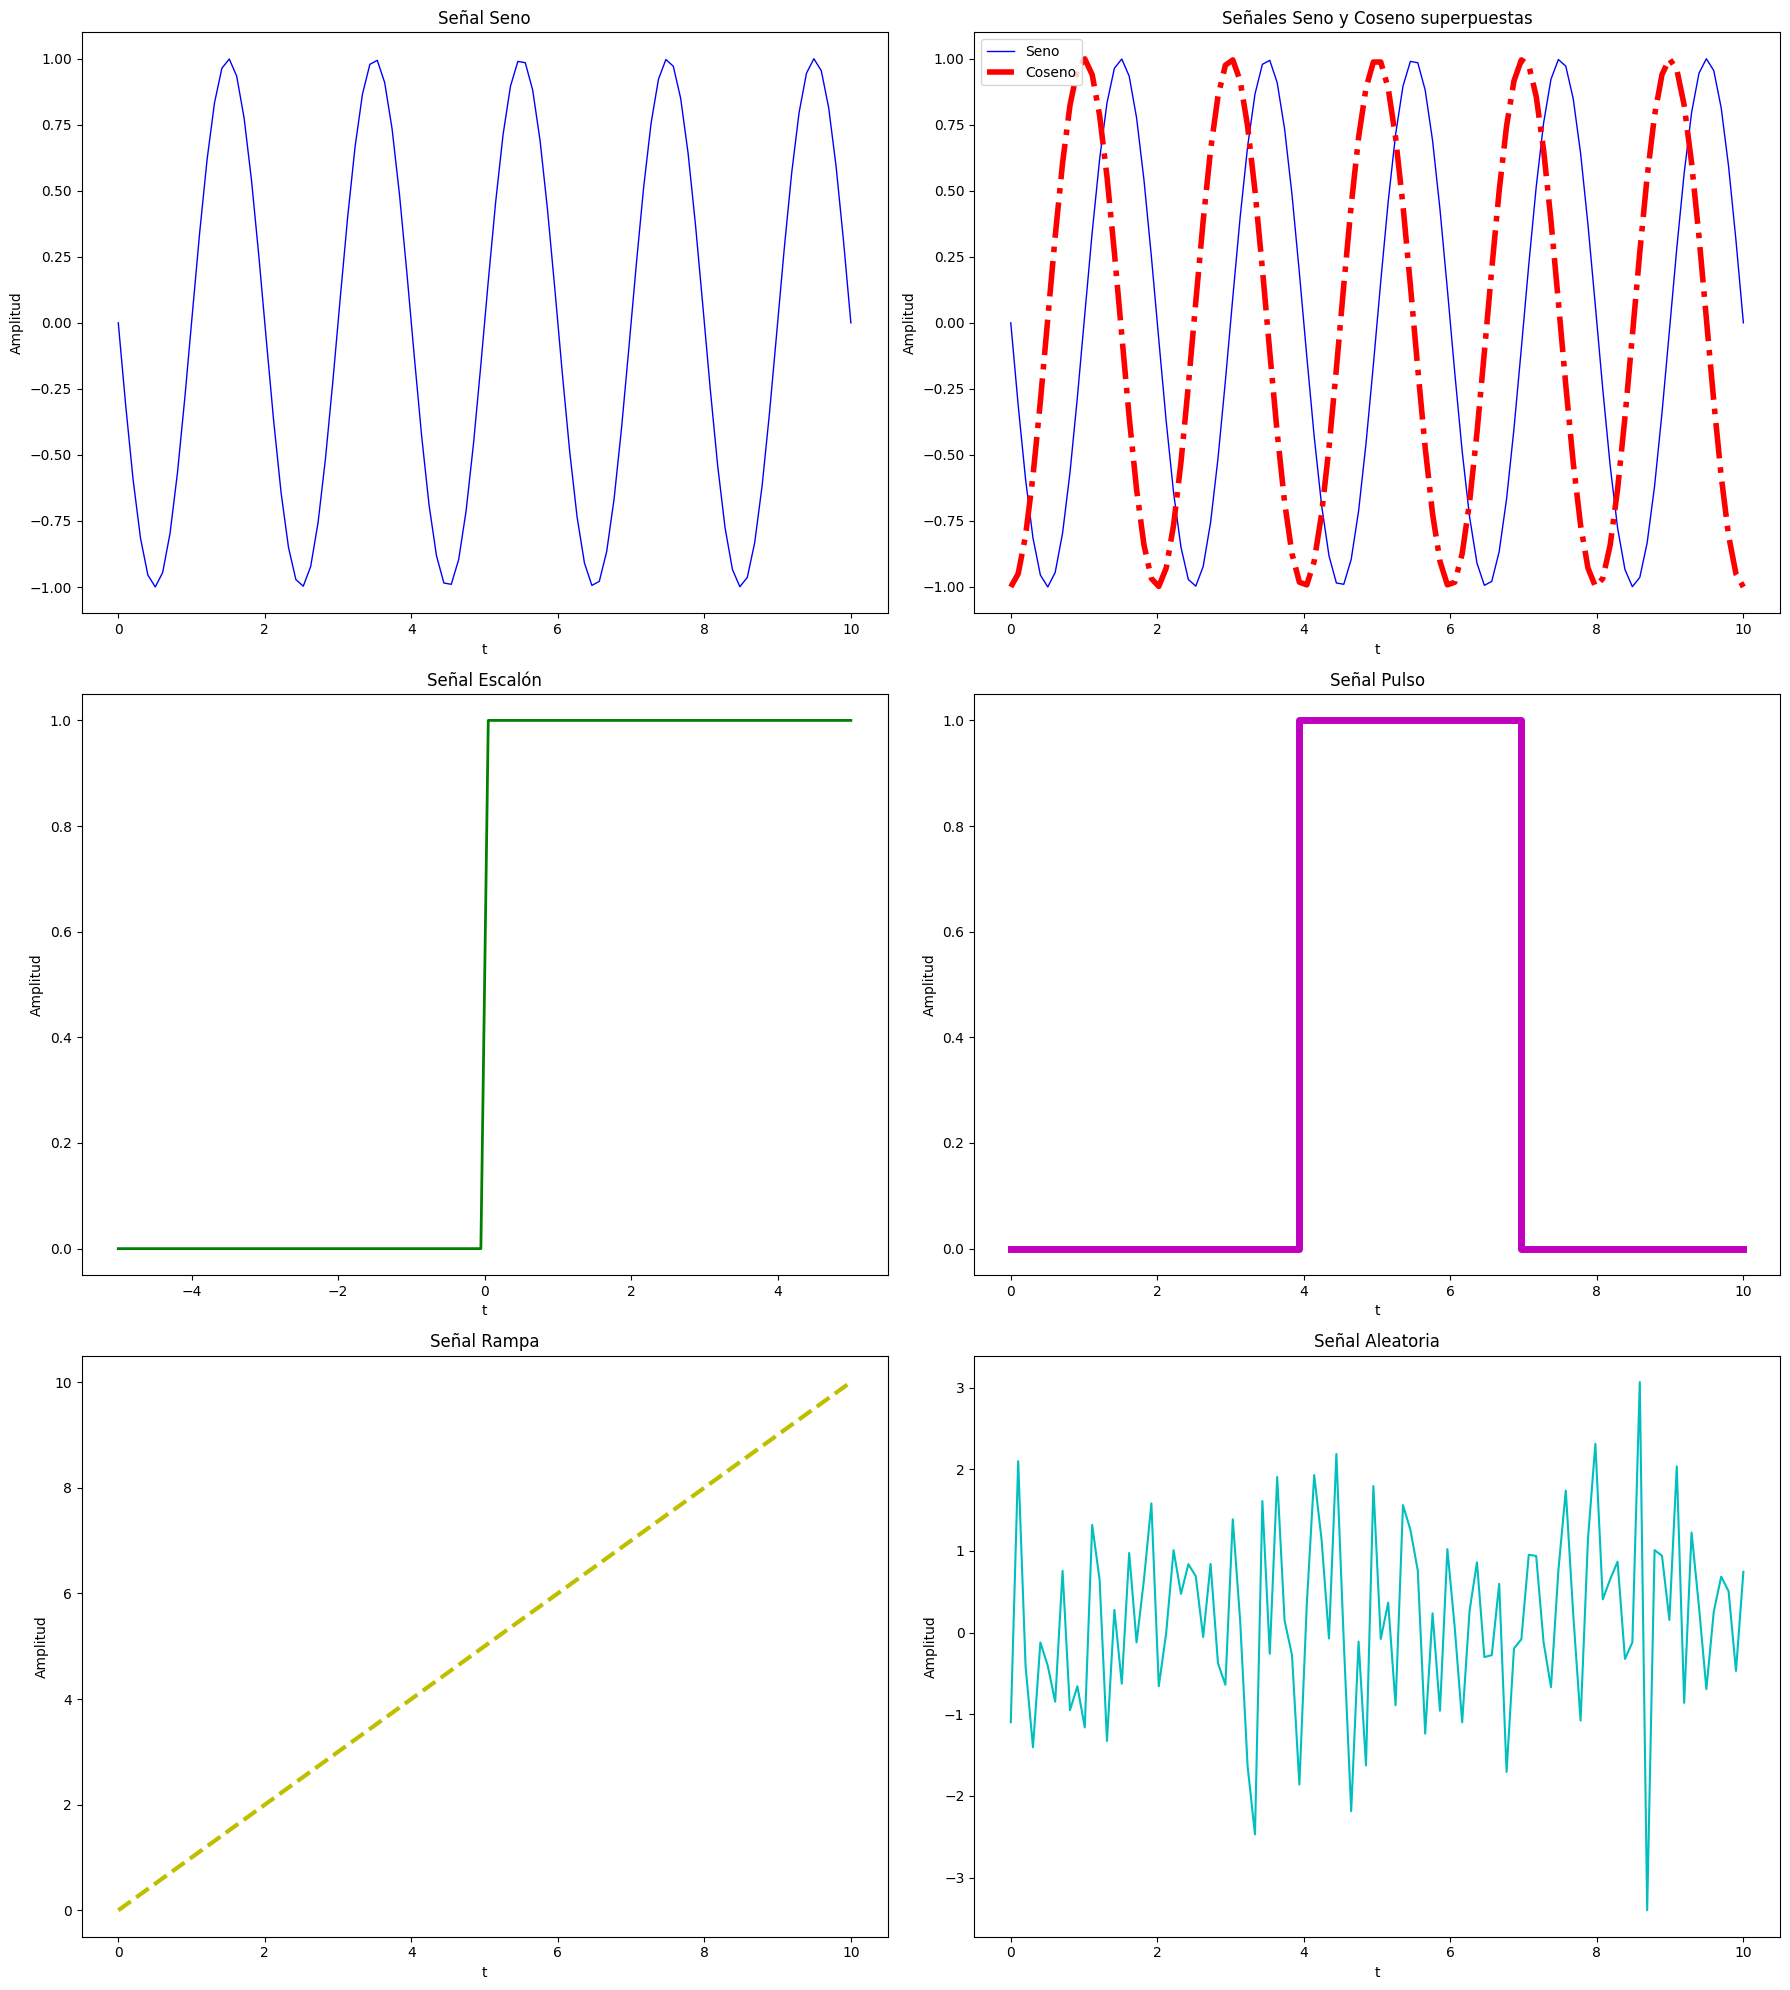

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(18, 20))
t = np.linspace(0,10,100)

#señal seno y coseno
amp = 1
fase = np.pi
freg = 0.5
sen=amp * np.sin(2*np.pi*freg*t+fase)
cos=amp * np.cos(2*np.pi*freg*t+fase)
axes[0,0].plot(t, sen, color='b', label='seno', linewidth=1)
axes[0,0].set_title('Señal Seno')
axes[0,0].set_xlabel('t')
axes[0,0].set_ylabel('Amplitud')
axes[0,1].plot(t, sen, color='b', label='Seno', linewidth=1)
axes[0,1].plot(t, cos, color='r', label='Coseno', linewidth=4, linestyle='-.')
axes[0,1].set_title('Señales Seno y Coseno superpuestas')
axes[0,1].set_xlabel('t')
axes[0,1].set_ylabel('Amplitud')
axes[0,1].legend()


#señal escalon
t_step = np.linspace(-5, 5, 100) #Cambiamos el tiempo para el escalón para usar
# la función heaviside de numpy y que se observe el cambio de salida
escalon = np.heaviside(t_step, 1)
axes[1,0].plot(t_step, escalon, color='g', label='escalon', linewidth=2)
axes[1,0].set_title('Señal Escalón')
axes[1,0].set_xlabel('t')
axes[1,0].set_ylabel('Amplitud')


#señal pulso
pulso= np.heaviside(t-4, 0) - np.heaviside(t-7, 0)
axes[1,1].step(t, pulso, color='m', linewidth=5)
axes[1,1].set_title('Señal Pulso')
axes[1,1].set_xlabel('t')
axes[1,1].set_ylabel('Amplitud')


#señal rampa
axes[2,0].plot(t, t, color='y', label='rampa', linewidth=3, linestyle='--')
axes[2,0].set_title('Señal Rampa')
axes[2,0].set_xlabel('t')
axes[2,0].set_ylabel('Amplitud')


#señal aleatoria
aleatoria = np.random.randn(len(t))
axes[2,1].plot(t, aleatoria, color='c', label='aleatoria')
axes[2,1].set_title('Señal Aleatoria')
axes[2,1].set_xlabel('t')
axes[2,1].set_ylabel('Amplitud')


plt.tight_layout()
plt.show()

# Ejercicio 2

En este ejercicio se busca trabajar con señales reales obtenidas a partir de una base de datos biomédica. La consigna propone levantar y visualizar este tipo de señales, pudiendo emplearse la base EPHNOGRAM, que contiene registros simultáneos de electrocardiograma y fonocardiograma.

## Carga del archivo de datos

Para acceder al contenido del archivo se utiliza la función `loadmat` de la librería `scipy.io`, ya que el archivo de entrada se encuentra en formato `.mat`. Este tipo de archivo permite almacenar variables provenientes de MATLAB u otros entornos de procesamiento numérico.

La instrucción utilizada es:

$$
\text{datos} = \text{loadmat}(\text{ruta del archivo})
$$

Con esto se carga en memoria una estructura que contiene todas las variables almacenadas en el archivo. Luego, mediante:

$$
\text{datos.keys()}
$$

se inspeccionan las claves disponibles para identificar qué variables corresponden a las señales y cuál representa la frecuencia de muestreo.

## Extracción de las señales

Una vez identificadas las claves del archivo, se asigna una variable a cada señal de interés:

- `ecg` para la señal de electrocardiograma;
- `pcg` para la señal de fonocardiograma;
- `fs` para la frecuencia de muestreo.

Además, se utiliza `squeeze()` para eliminar dimensiones innecesarias y transformar los datos en arreglos unidimensionales, de manera que puedan manipularse y graficarse de forma más sencilla.

In [ ]:
from scipy.io import loadmat

datos = loadmat("/ECGPCG0030.mat")
print(datos.keys())

#Una vez obtenidos los keys del archivo, le asigno un nombre de variable al contenido:
ecg = datos["ECG"].squeeze()
pcg = datos["PCG"].squeeze()
fs = datos["fs"].squeeze()

print("Forma ECG:", ecg.shape)
print("Forma PCG:", pcg.shape)
print("Frecuencia de muestreo:", fs, "Hz")

dict_keys(['__header__', '__version__', '__globals__', 'AUX1', 'AUX2', 'ECG', 'PCG', 'PCG2', 'fs'])
Forma ECG: (14400000,)
Forma PCG: (14400000,)
Frecuencia de muestreo: 8000 Hz


## Visualización de las señales reales

Una vez cargadas las señales y conocida la frecuencia de muestreo, el siguiente paso consiste en representarlas gráficamente en función del tiempo. Para ello es necesario construir un eje temporal adecuado, ya que las señales provienen de un registro discreto y cada muestra se encuentra separada por un intervalo de tiempo determinado por la frecuencia de muestreo.

## Construcción del eje temporal

Si la frecuencia de muestreo es $f_s$, entonces el intervalo entre muestras es:

$$
T_s = \frac{1}{f_s}
$$

A partir de esta información, se construye un vector temporal para representar una cierta duración del registro. En este caso se decide mostrar solamente un tramo de las señales, fijando:

$$
MAX = 10
$$

lo que implica visualizar los primeros 10 segundos del registro.

Luego se construye el eje temporal mediante:

$$
t = \text{linspace}(0, MAX, f_s)
$$

De esta manera se obtiene un conjunto de instantes igualmente espaciados entre 0 y 10 segundos, que se utiliza como eje horizontal para graficar las señales.

## Señales representadas

### 1. Señal ECG

### 2. Señal PCG

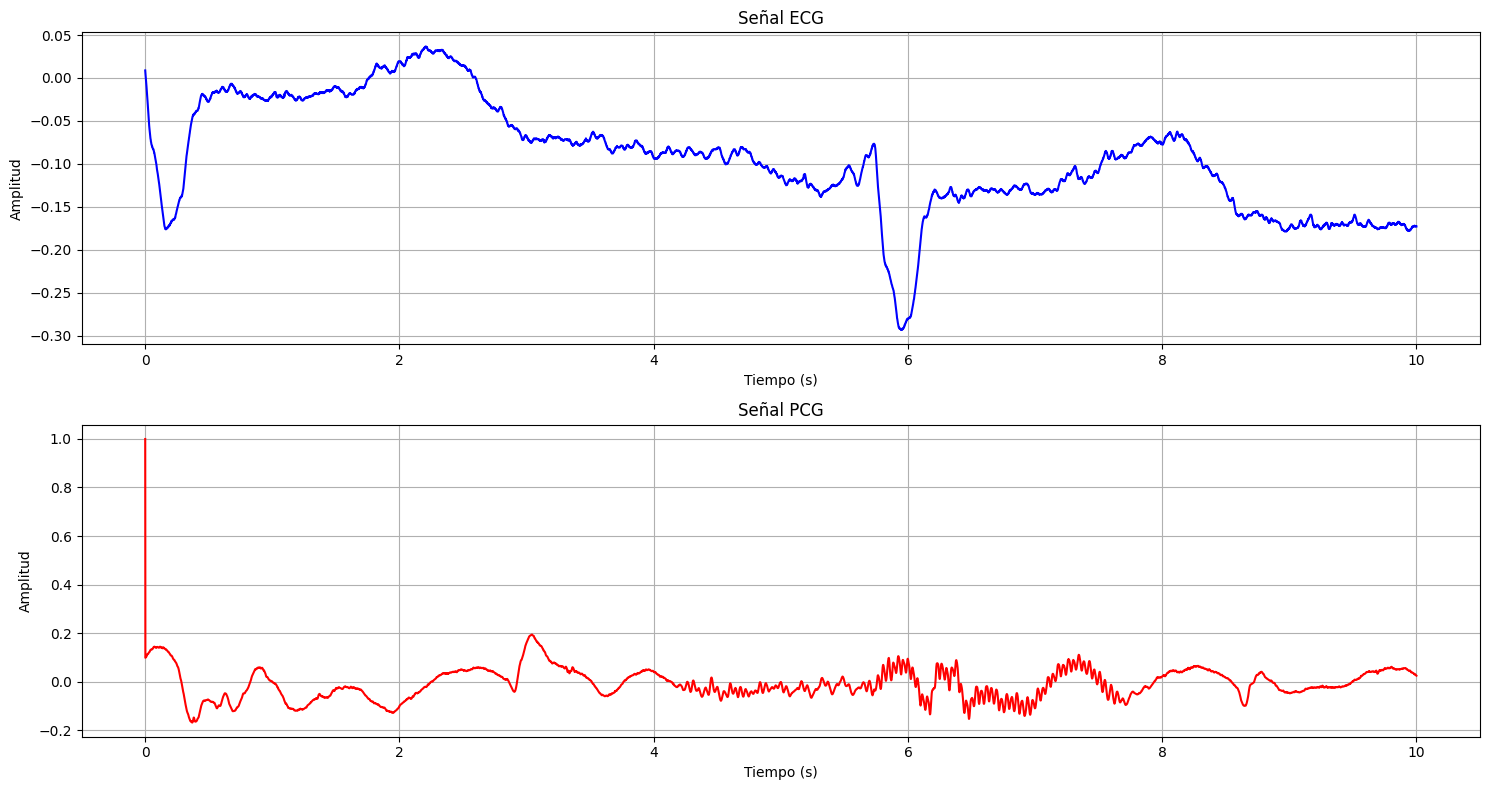

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

MAX = 10 #Elegimos hasta donde quiero mostrar en segundos

t = np.linspace(0,MAX, fs) #Creamos un array que va desde 0 hasta MAX, en pasos de cantidad fs
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

# plot señal ECG
ax1.plot(t, ecg[:len(t)], color='blue')
ax1.set_title('Señal ECG')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud')
ax1.grid(True)

# plot señal PCG
ax2.plot(t, pcg[:len(t)], color='red')
ax2.set_title('Señal PCG')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Amplitud')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Ejercicio 3

En este ejercicio se busca simular señales discretas a partir de las señales continuas trabajadas previamente. La consigna indica avanzar desde la representación *"continua"* hacia una representación discreta, introduciendo la idea de muestreo y analizando cómo cambia la visualización de las señales al considerar un conjunto finito de muestras.

## Idea de discretización

En tiempo continuo, una señal está definida para todo instante de tiempo dentro de un intervalo. En cambio, en tiempo discreto la señal queda representada solo en determinados instantes. Desde el punto de vista práctico, esto equivale a muestrear la señal continua y conservar únicamente ciertos valores.

En el código se construyen dos arreglos temporales:

$$
t = \text{linspace}(-4, 4, \text{MAS\_MUESTRAS})
$$

$$
t_d = \text{linspace}(-4, 4, \text{MENOS\_MUESTRAS})
$$

De esta manera:

- `t` representa una discretización más densa del intervalo;
- `t_d` representa una discretización más espaciada.

Esto permite comparar dos formas de muestrear una misma señal y observar cómo la reducción en la cantidad de muestras modifica su apariencia visual.

## Tipo de gráficos utilizados

Para representar las señales discretas se utiliza la función `stem`, que resulta apropiada para secuencias discretas porque muestra cada valor como una muestra aislada asociada a un instante específico.

## Señales simuladas

### 1. Señal senoidal

### 2. Señal escalón

### 3. Señal pulso

### 4. Señal rampa

### 5. Señal aleatoria

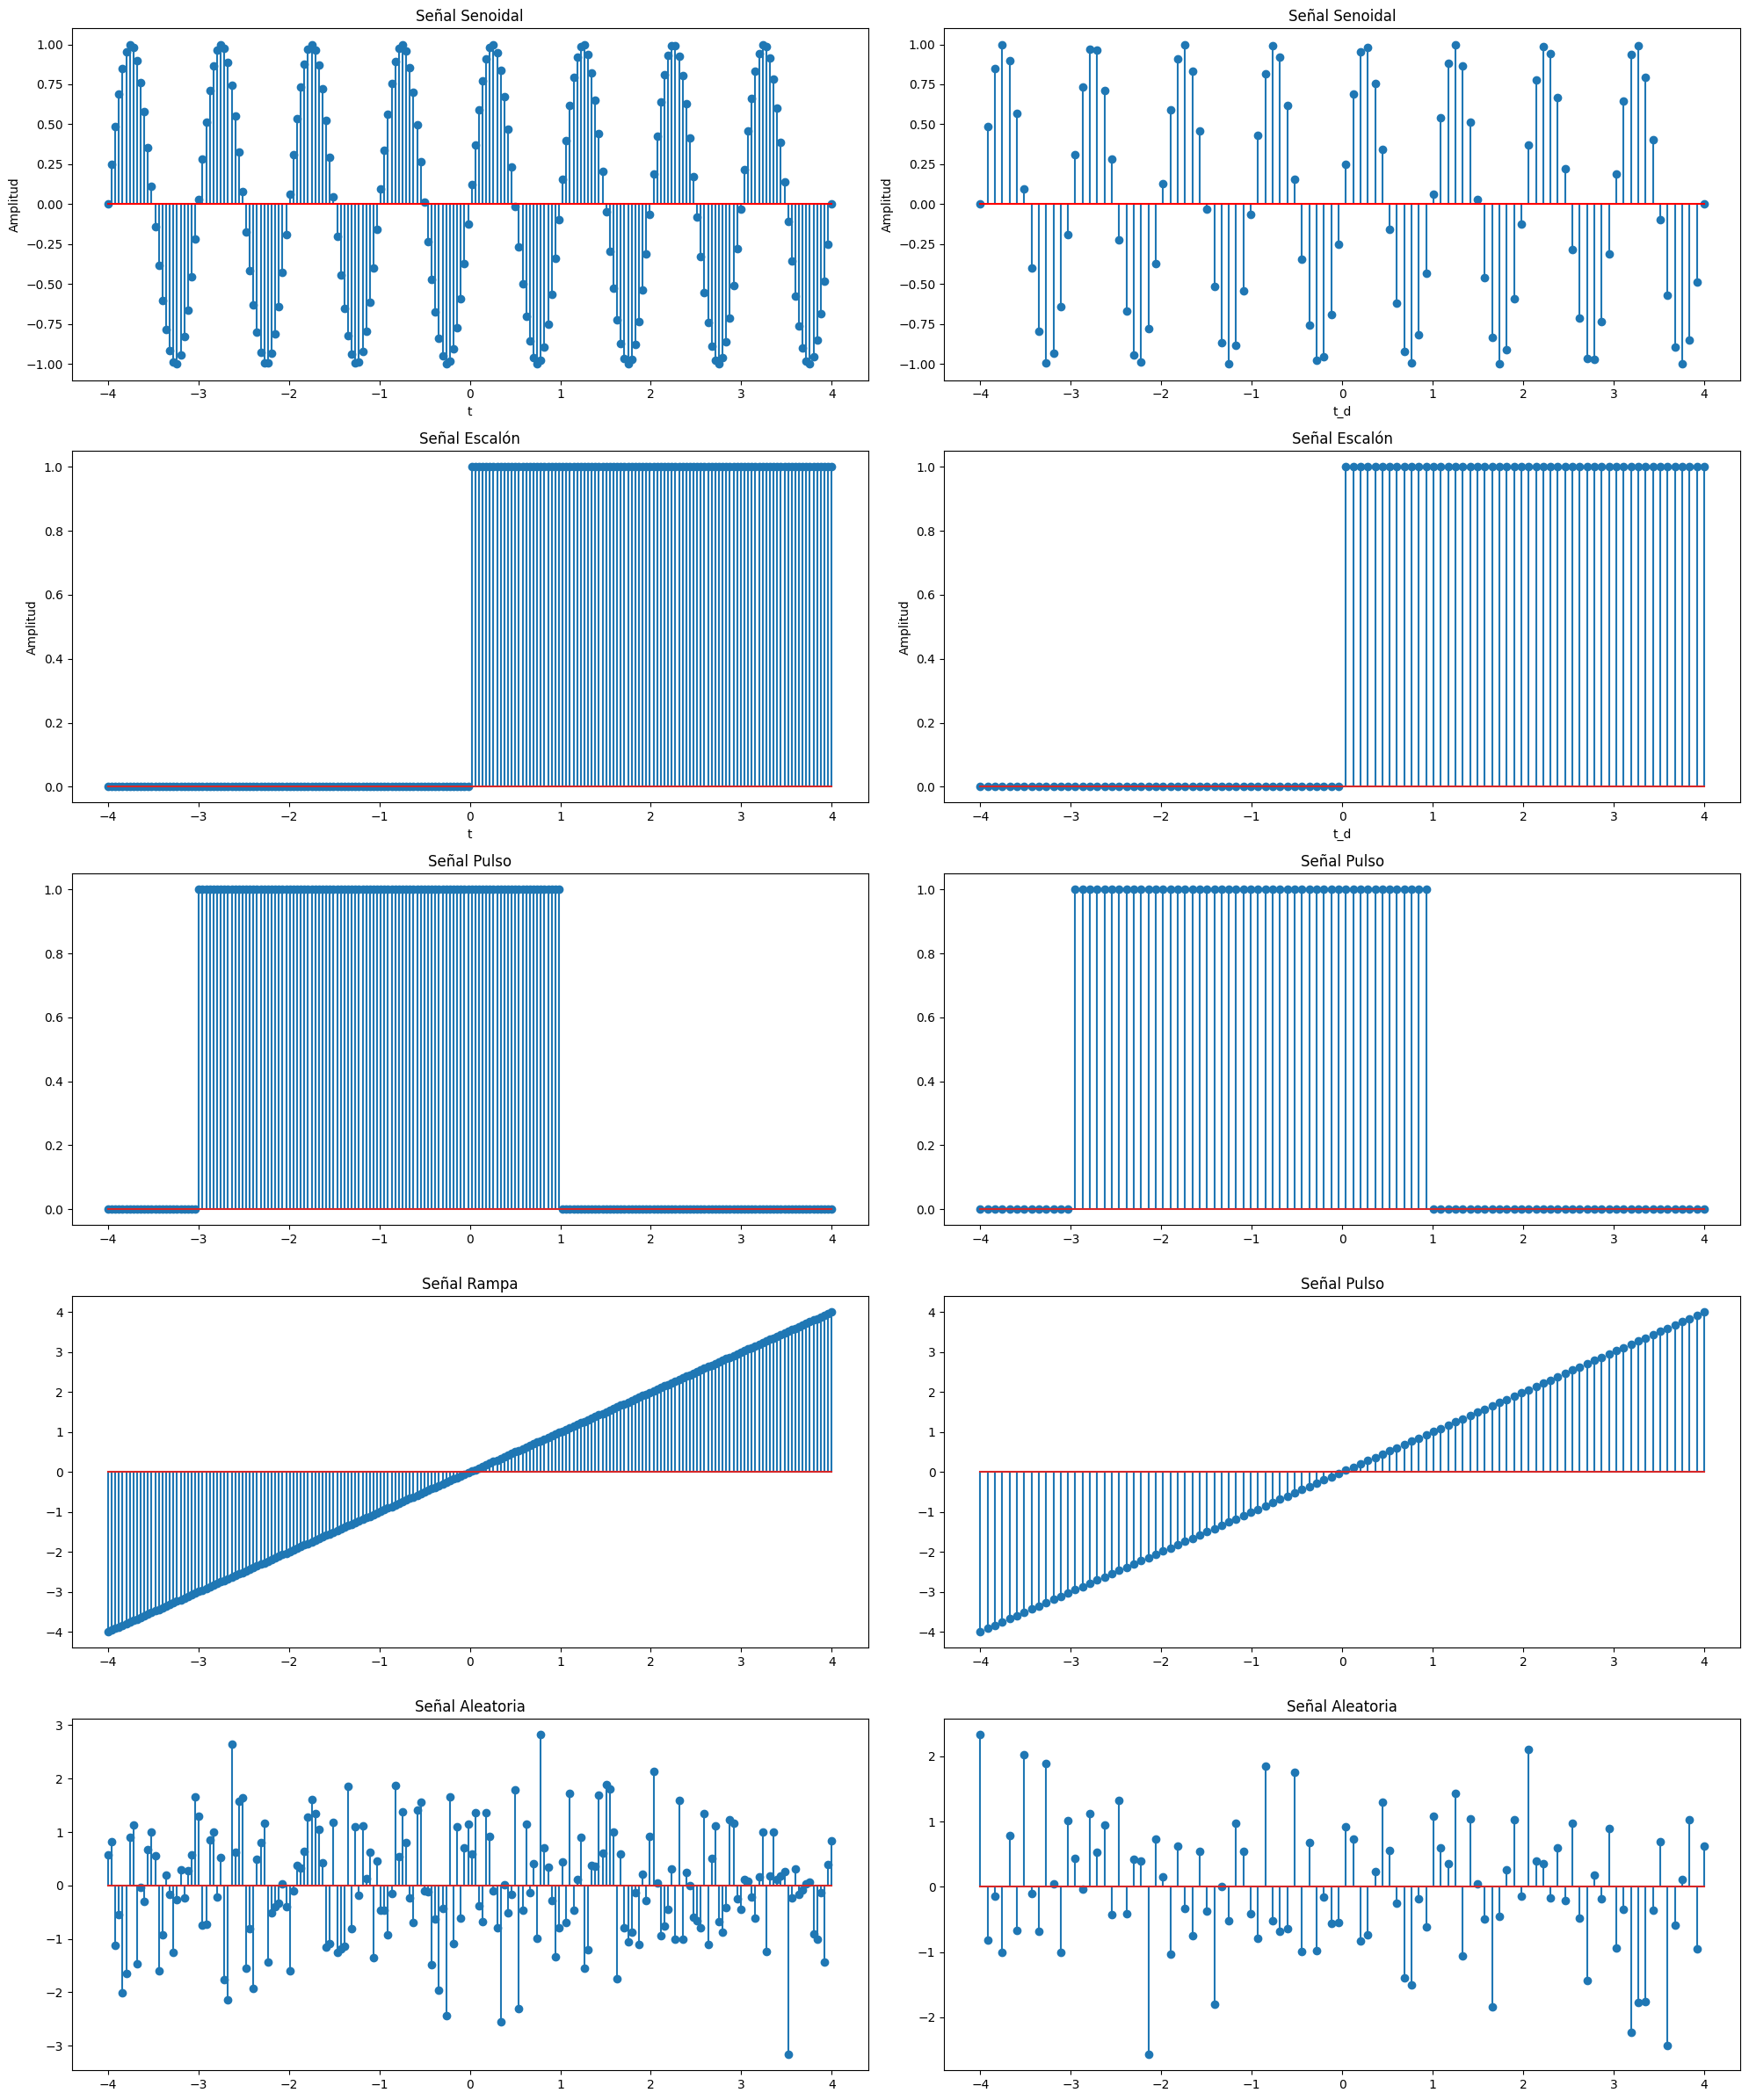

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

MAS_MUESTRAS = 200
MENOS_MUESTRAS = 100

t= np.linspace(-4, 4,MAS_MUESTRAS)

#Reducimos la cantidad de muestras en el tiempo:
t_d = np.linspace(-4, 4, MENOS_MUESTRAS)


fig, axes = plt.subplots(5, 2, figsize=(20, 24))

# Señal senoidal
axes[0, 0].stem(t, np.sin(2*np.pi*t), bottom=0, basefmt='r-')
axes[0, 0].set_title('Señal Senoidal')
axes[0, 0].set_xlabel('t')
axes[0, 0].set_ylabel('Amplitud')

axes[0, 1].stem(t_d, np.sin(2*np.pi*t_d), bottom=0, basefmt='r-')
axes[0, 1].set_title('Señal Senoidal')
axes[0, 1].set_xlabel('t_d')
axes[0, 1].set_ylabel('Amplitud')

# Señal escalón
axes[1, 0].stem(t, np.heaviside(t, 1), bottom=0)
axes[1, 0].set_title('Señal Escalón')
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('Amplitud')

axes[1, 1].stem(t_d, np.heaviside(t_d, 1), bottom=0)
axes[1, 1].set_title('Señal Escalón')
axes[1, 1].set_xlabel('t_d')
axes[1, 1].set_ylabel('Amplitud')

# Señal pulso
pulso= np.heaviside(t+3, 0) - np.heaviside(t-1, 0)
axes[2, 0].stem(t, pulso, bottom=0)
axes[2, 0].set_title('Señal Pulso')
pulso_d = np.heaviside(t_d+3, 0) - np.heaviside(t_d-1, 0)
axes[2, 1].stem(t_d, pulso_d, bottom=0)
axes[2, 1].set_title('Señal Pulso')

# Señal rampa
axes[3, 0].stem(t, t, bottom=0)
axes[3, 0].set_title('Señal Rampa')
axes[3, 1].stem(t_d, t_d, bottom=0)
axes[3, 1].set_title('Señal Pulso')

# Señal aleatoria
aleatoria = np.random.randn(len(t))
axes[4, 0].stem(t, aleatoria, bottom=0)
axes[4, 0].set_title('Señal Aleatoria')
aleatoria_d = np.random.randn(len(t_d))
axes[4, 1].stem(t_d, aleatoria_d, bottom=0)
axes[4, 1].set_title('Señal Aleatoria')


plt.tight_layout()
plt.show()

# Ejercicio 4

En este ejercicio se estudia el circuito en serie compuesto por una inductancia $L$, una resistencia $R_1$, un capacitor $C$ y una resistencia $R_c$, tomando como entrada la fuente $V_s(t)$ y como salida la tensión sobre la resistencia $R_c$, es decir:

$$
v_{out}(t)=v_{R_c}(t)
$$

El objetivo es obtener la función de transferencia del sistema, identificar sus parámetros principales en la forma normalizada y luego analizar su comportamiento en frecuencia y en el tiempo.


## Obtención de la función de transferencia

Dado que es un sistema en serie, la corriente es la misma en todos los elementos. Entonces:

$$
v_{out}(t)=R_c\,i(t)
$$

Aplicando la Ley de Kirchhoff de mallas:

$$
V_s(t)=v_L(t)+v_{R_1}(t)+v_C(t)+v_{R_c}(t)
$$

Reemplazando cada tensión por su relación con la corriente:

$$
V_s(t)=L\frac{di(t)}{dt}+R_1\,i(t)+v_C(t)+R_c\,i(t)
$$

Como la salida está definida sobre la resistencia $R_c$:

$$
v_{out}(t)=R_c\,i(t)
\qquad \Rightarrow \qquad
i(t)=\frac{v_{out}(t)}{R_c}
$$

Además, para el capacitor se cumple:

$$
i(t)=C\frac{dv_C(t)}{dt}
$$

Entonces:

$$
\frac{dv_C(t)}{dt}=\frac{i(t)}{C}=\frac{v_{out}(t)}{R_cC}
$$

Sustituyendo $i(t)=\dfrac{v_{out}(t)}{R_c}$ en la ecuación de malla:

$$
V_s(t)=L\frac{d}{dt}\left(\frac{v_{out}(t)}{R_c}\right)+R_1\frac{v_{out}(t)}{R_c}+v_C(t)+v_{out}(t)
$$

$$
V_s(t)=\frac{L}{R_c}\frac{dv_{out}(t)}{dt}+\frac{R_1+R_c}{R_c}v_{out}(t)+v_C(t)
$$

Para eliminar la variable $v_C(t)$, se deriva toda la ecuación:

$$
\frac{dV_s(t)}{dt}
=
\frac{L}{R_c}\frac{d^2v_{out}(t)}{dt^2}
+
\frac{R_1+R_c}{R_c}\frac{dv_{out}(t)}{dt}
+
\frac{dv_C(t)}{dt}
$$

Y como:

$$
\frac{dv_C(t)}{dt}=\frac{v_{out}(t)}{R_cC}
$$

resulta:

$$
\frac{dV_s(t)}{dt}
=
\frac{L}{R_c}\frac{d^2v_{out}(t)}{dt^2}
+
\frac{R_1+R_c}{R_c}\frac{dv_{out}(t)}{dt}
+
\frac{1}{R_cC}v_{out}(t)
$$

Multiplicando toda la ecuación por $R_c$:

$$
R_c\frac{dV_s(t)}{dt}
=
L\frac{d^2v_{out}(t)}{dt^2}
+
(R_1+R_c)\frac{dv_{out}(t)}{dt}
+
\frac{1}{C}v_{out}(t)
$$

Por lo tanto, la ecuación diferencial del sistema es:

$$
L\frac{d^2v_{out}(t)}{dt^2}
+
(R_1+R_c)\frac{dv_{out}(t)}{dt}
+
\frac{1}{C}v_{out}(t)
=
R_c\frac{dV_s(t)}{dt}
$$



## Obtención de $H(s)$

Aplicando Transformada de Laplace con condiciones iniciales nulas:

$$
L s^2 V_{out}(s) + (R_1+R_c)sV_{out}(s) + \frac{1}{C}V_{out}(s)=R_c s V_s(s)
$$

Factorizando $V_{out}(s)$:

$$
V_{out}(s)\left(L s^2 + (R_1+R_c)s + \frac{1}{C}\right)=R_c s V_s(s)
$$

Entonces, la función de transferencia queda:

$$
H(s)=\frac{V_{out}(s)}{V_s(s)}
=
\frac{R_c s}{L s^2 + (R_1+R_c)s + \frac{1}{C}}
$$


## Forma normalizada de la función de transferencia

Para identificar más fácilmente los parámetros del sistema, se divide numerador y denominador por $L$:

$$
H(s)=
\frac{\frac{R_c}{L}s}{s^2+\frac{R_1+R_c}{L}s+\frac{1}{LC}}
$$

Esta es la forma normalizada de la función de transferencia.


## Identificación de $\omega_0$ y del ancho de banda

Comparando la función obtenida con la forma típica de un sistema pasa banda de segundo orden:

$$
H(s)=\frac{K\,s}{s^2 + BW\,s + \omega_0^2}
$$

se identifican directamente:

$$
\omega_0^2=\frac{1}{LC}
\qquad \Rightarrow \qquad
\omega_0=\sqrt{\frac{1}{LC}}
$$

y

$$
BW=\frac{R_1+R_c}{L}
$$

Por lo tanto:

- $\omega_0$ representa la frecuencia angular central del sistema.
- $BW$ representa el ancho de banda del filtro pasa banda.

Además, utilizando una aproximación teórica para las frecuencias de corte:

$$
\omega_1=\omega_0-\frac{BW}{2}
\qquad\qquad
\omega_2=\omega_0+\frac{BW}{2}
$$


## Cálculo numérico

Los valores del circuito son:

- $L=330\,\mu H=330\times10^{-6}\,H$
- $R_1=4.7\,\Omega$
- $R_c=56\,\Omega$
- $C=33\,nF=33\times10^{-9}\,F$

### Frecuencia angular central

$$
\omega_0=\sqrt{\frac{1}{LC}}
$$

$$
\omega_0=\sqrt{\frac{1}{(330\times10^{-6})(33\times10^{-9})}}
$$

$$
\omega_0 \approx 3.03\times10^5 \, \text{rad/s}
$$

En frecuencia:

$$
f_0=\frac{\omega_0}{2\pi}\approx 4.82\times10^4 \,\text{Hz}
$$

$$
f_0 \approx 48.2 \,\text{kHz}
$$

### Ancho de banda

$$
BW=\frac{R_1+R_c}{L}
$$

$$
BW=\frac{4.7+56}{330\times10^{-6}}
$$

$$
BW\approx 1.84\times10^5 \,\text{rad/s}
$$

En frecuencia:

$$
BW_f=\frac{BW}{2\pi}\approx 2.93\times10^4 \,\text{Hz}
$$

$$
BW_f \approx 29.3 \,\text{kHz}
$$

### Frecuencias de corte aproximadas

$$
\omega_1=\omega_0-\frac{BW}{2}
\qquad\qquad
\omega_2=\omega_0+\frac{BW}{2}
$$

$$
\omega_1 \approx 2.11\times10^5 \,\text{rad/s}
$$

$$
\omega_2 \approx 3.95\times10^5 \,\text{rad/s}
$$

En Hz:

$$
f_1=\frac{\omega_1}{2\pi}\approx 33.6\,\text{kHz}
\qquad\qquad
f_2=\frac{\omega_2}{2\pi}\approx 62.8\,\text{kHz}
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

L = 330e-6
R1 = 4.7
C = 33e-9
Rc = 56

numerador = [Rc / L, 0]
denominador = [1, (R1 + Rc) / L, 1 / (L * C)]

sys_tf = signal.TransferFunction(numerador, denominador)

w0 = 1 / np.sqrt(L * C)
BW = (R1 + Rc) / L
w1 = w0 - BW/2
w2 = w0 + BW/2

## Obtención del diagrama de Bode

Una vez obtenida la función de transferencia del sistema en forma normalizada,

$$
H(s)=\frac{\frac{R_c}{L}s}{s^2+\frac{R_1+R_c}{L}s+\frac{1}{LC}}
$$

para construir el diagrama de Bode se reemplaza la variable compleja $s$ por $j\omega$.

Entonces:

$$
H(j\omega)=\frac{\frac{R_c}{L}(j\omega)}{(j\omega)^2+\frac{R_1+R_c}{L}(j\omega)+\frac{1}{LC}}
$$

Como $(j\omega)^2=-\omega^2$, queda:

$$
H(j\omega)=\frac{\frac{R_c}{L}(j\omega)}{-\omega^2+j\omega\frac{R_1+R_c}{L}+\frac{1}{LC}}
$$

Reordenando el denominador:

$$
H(j\omega)=\frac{\frac{R_c}{L}(j\omega)}{\left(\frac{1}{LC}-\omega^2\right)+j\omega\frac{R_1+R_c}{L}}
$$


## Cálculo del módulo

Para construir el diagrama de magnitud, primero se necesita calcular el módulo de la función de transferencia evaluada en $j\omega$.

El módulo del numerador es:

$$
\left|\frac{R_c}{L}(j\omega)\right|=\frac{R_c}{L}\omega
$$

y el módulo del denominador es:

$$
\sqrt{\left(\frac{1}{LC}-\omega^2\right)^2+\left(\omega\frac{R_1+R_c}{L}\right)^2}
$$

Por lo tanto, el módulo total queda:

$$
|H(j\omega)|=
\frac{\frac{R_c}{L}\omega}
{\sqrt{\left(\frac{1}{LC}-\omega^2\right)^2+\left(\omega\frac{R_1+R_c}{L}\right)^2}}
$$

Para el diagrama de Bode, la magnitud se expresa en decibeles:

$$
|H(j\omega)|_{dB}=20\log_{10}(|H(j\omega)|)
$$

## Cálculo de la fase

La fase de la función de transferencia se obtiene como la diferencia entre la fase del numerador y la fase del denominador.

La fase del numerador es la fase de $j\omega$, que vale:

$$
\angle(j\omega)=90^\circ
$$

La fase del denominador, al ser un número complejo de la forma $a+jb$, se calcula como:

$$
\theta_D=\tan^{-1}\left(\frac{b}{a}\right)
$$

En este caso:

$$
a=\frac{1}{LC}-\omega^2
\qquad\qquad
b=\omega\frac{R_1+R_c}{L}
$$

Entonces la fase del denominador es:

$$
\theta_D=
\tan^{-1}
\left(
\frac{\omega\frac{R_1+R_c}{L}}
{\frac{1}{LC}-\omega^2}
\right)
$$

Por lo tanto, la fase total del sistema es:

$$
\angle H(j\omega)=
90^\circ-
\tan^{-1}
\left(
\frac{\omega\frac{R_1+R_c}{L}}
{\frac{1}{LC}-\omega^2}
\right)
$$

## Construcción del Bode

Una vez obtenidos el módulo y la fase, se puede construir el diagrama de Bode del sistema.

Además, sobre el gráfico se marcan los parámetros teóricos del sistema:

$$
\omega_0=\sqrt{\frac{1}{LC}}
$$

$$
BW=\frac{R_1+R_c}{L}
$$

y, utilizando la aproximación:

$$
\omega_1=\omega_0-\frac{BW}{2}
\qquad\qquad
\omega_2=\omega_0+\frac{BW}{2}
$$

se indican también las frecuencias de corte aproximadas y el ancho de banda.

A continuación se muestra el código utilizado para programar el diagrama de Bode del sistema y su fase.

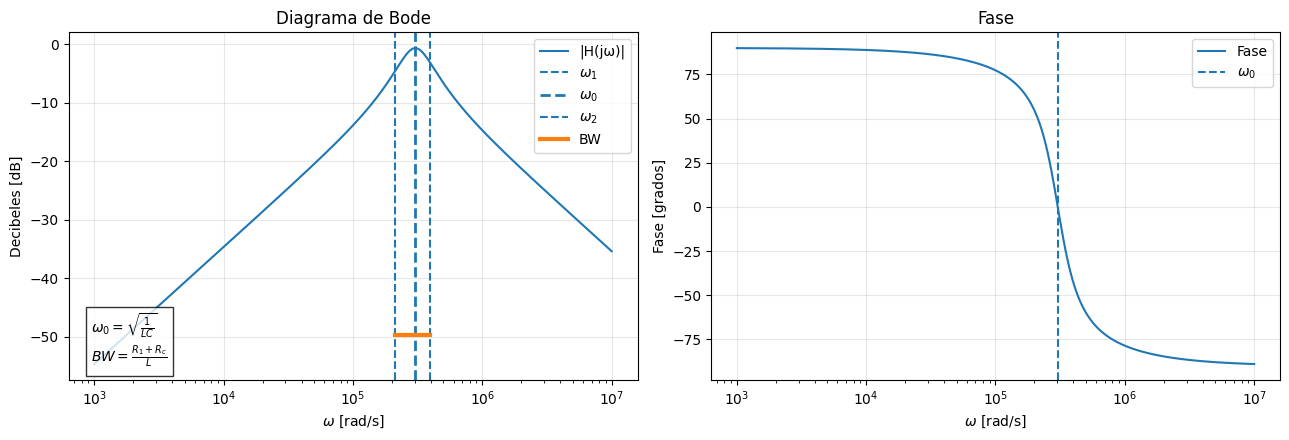

In [ ]:
w = np.logspace(3, 7, 4000)
w, mag_db, phase_deg = signal.bode(sys_tf, w=w)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.semilogx(w, mag_db, label='|H(jω)|')
ax1.set_title('Diagrama de Bode')
ax1.set_xlabel(r'$\omega$ [rad/s]')
ax1.set_ylabel('Decibeles [dB]')
ax1.grid(True, alpha=0.3)

ax1.axvline(w1, linestyle='--', linewidth=1.5, label=r'$\omega_1$')
ax1.axvline(w0, linestyle='--', linewidth=2.0, label=r'$\omega_0$')
ax1.axvline(w2, linestyle='--', linewidth=1.5, label=r'$\omega_2$')

y_bw = np.min(mag_db) + 5
ax1.plot([w1, w2], [y_bw, y_bw], linewidth=3, label='BW')

texto_bode = (
    r'$\omega_0 = \sqrt{\frac{1}{LC}}$' + '\n' +
    r'$BW = \frac{R_1 + R_c}{L}$'
)
ax1.text(0.04, 0.05, texto_bode, transform=ax1.transAxes,
         fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

ax1.legend(loc='best')

ax2.semilogx(w, phase_deg, label='Fase')
ax2.set_title('Fase')
ax2.set_xlabel(r'$\omega$ [rad/s]')
ax2.set_ylabel('Fase [grados]')
ax2.grid(True, alpha=0.3)
ax2.axvline(w0, linestyle='--', linewidth=1.5, label=r'$\omega_0$')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

## Elección de las frecuencias angulares de prueba y simulaciones temporales

Una vez caracterizado el sistema en el dominio de la frecuencia a partir de su función de transferencia y de su diagrama de Bode, se simula la respuesta del circuito ante distintas señales de entrada, con el objetivo de verificar experimentalmente el comportamiento pasa banda obtenido teóricamente.

## Elección de los valores de $\omega$

Dado que el sistema se comporta como un filtro pasa banda, no todas las frecuencias se transmiten de la misma manera hacia la salida. En particular:

- las frecuencias muy bajas se atenúan;
- las frecuencias cercanas a la frecuencia central $\omega_0$ se transmiten con mayor amplitud;
- las frecuencias muy altas también se atenúan.

Por este motivo, para analizar el comportamiento del sistema seleccionamos distintos valores de frecuencia angular $\omega$ ubicados en regiones representativas del pasa banda. En este caso no solo consideramos frecuencias cercanas a la banda, sino también dos casos extremos, con el fin de mostrar de manera más evidente la atenuación en los extremos del espectro.

En particular, se analizan:

- una frecuencia extremadamente por debajo de la banda;
- una frecuencia muy por debajo de la banda;
- una frecuencia por debajo de la banda pero más cercana al borde;
- el borde inferior de la banda, dado por $\omega_1$;
- la frecuencia central, dada por $\omega_0$;
- el borde superior de la banda, dado por $\omega_2$;
- una frecuencia por encima de la banda;
- una frecuencia muy por encima de la banda;
- una frecuencia extremadamente por encima de la banda.

De este modo, las señales elegidas nos permiten observar cómo cambia la respuesta del sistema a medida que la frecuencia angular de la entrada se desplaza desde la zona de atenuación inferior, atraviesa la banda de paso y luego se dirige hacia la zona de atenuación superior.

Se toman las siguientes frecuencias angulares de prueba:

$$
\omega_{1} = 0.01\,\omega_1
$$

$$
\omega_{2} = 0.1\,\omega_1
$$

$$
\omega_{3} = 0.5\,\omega_1
$$

$$
\omega_{4} = \omega_1
$$

$$
\omega_{5} = \omega_0
$$

$$
\omega_{6} = \omega_2
$$

$$
\omega_{7} = 1.5\,\omega_2
$$

$$
\omega_{8} = 3\,\omega_2
$$

$$
\omega_{9} = 10\,\omega_2
$$

La elección de estos valores nos permite recorrer el comportamiento del sistema de forma ordenada y mostrar claramente que la mayor transmisión ocurre en torno a la banda de paso, mientras que la atenuación se vuelve mucho más marcada para frecuencias muy alejadas de ella.

## Simulación de las señales senoidales

Para cada frecuencia angular seleccionada, se define una señal de entrada senoidal de la forma:

$$
v_s(t)=A\sin(\omega t)
$$

donde $A$ es la amplitud de la señal y $\omega$ es la frecuencia angular elegida para cada caso.

La respuesta temporal del sistema se obtiene simulando la salida frente a cada una de estas entradas. Para que la comparación entre los distintos casos sea clara, en cada simulación se utiliza un intervalo temporal adaptado al período de la señal, de manera de visualizar varios ciclos completos. Recordando que el período está dado por:

$$
T=\frac{2\pi}{\omega}
$$

se construye para cada caso un vector temporal que abarque varios períodos de la senoidal. Esto permite observar con claridad tanto la señal de entrada como la señal de salida, y comparar cómo varía la amplitud transmitida según la frecuencia angular aplicada.

En el código, este procedimiento se implementa definiendo para cada caso:

- el período de la señal;
- el vector temporal correspondiente;
- la señal de entrada senoidal;
- la señal de salida obtenida mediante simulación del sistema.

De esta forma, cada simulación queda asociada a una frecuencia angular específica y puede analizarse de manera individual.

## Gráfico de las respuestas senoidales

Una vez simulada la respuesta temporal para cada valor de $\omega$, se grafican en un mismo eje:

- la señal de entrada;
- la señal de salida.

Esta representación permite comparar directamente la excitación aplicada con la respuesta obtenida. A partir de estos gráficos puede observarse que:

- para valores de $\omega$ muy bajos, la salida es pequeña;
- al acercarse a la banda de paso, la salida aumenta;
- alrededor de $\omega_0$, la salida presenta mayor amplitud;
- al superar la banda, la salida vuelve a disminuir;
- para valores extremos, tanto muy pequeños como muy grandes, la atenuación se vuelve mucho más evidente.

Además de los gráficos individuales, también realizamos una figura resumen con todas las respuestas, para facilitar la comparación global entre los distintos casos.

## Respuesta ante una señal aleatoria

Además de las senoidales, resulta interesante estudiar la respuesta del sistema frente a una señal aleatoria. Este tipo de entrada contiene múltiples componentes frecuenciales distribuidas en un rango amplio, por lo que permite observar cómo el sistema filtra una señal más compleja que una simple senoide.

## Respuesta ante una señal escalón

También se estudia la respuesta del sistema frente a una entrada escalón. Esta señal resulta importante porque permite analizar el comportamiento transitorio del circuito y su respuesta ante una entrada de valor constante aplicada abruptamente.

En este caso, la simulación es especialmente relevante porque el circuito posee un capacitor en serie. Debido a ello, en régimen permanente no circula corriente continua, por lo que la tensión sobre la resistencia $R_c$ tiende a anularse con el tiempo. En consecuencia, frente a una entrada escalón, se espera observar una respuesta transitoria inicial seguida de una salida que decae hacia cero.

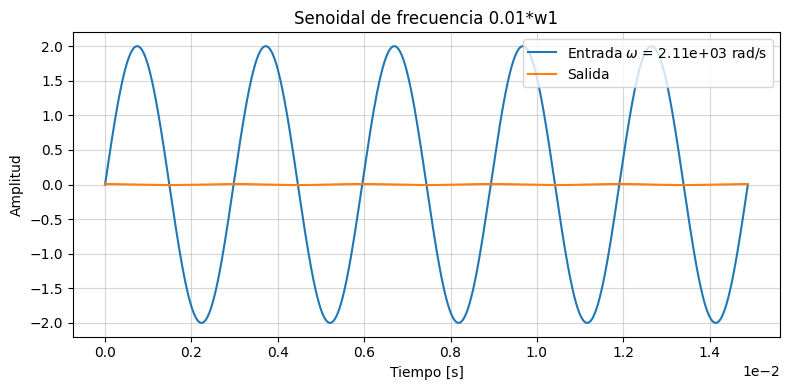

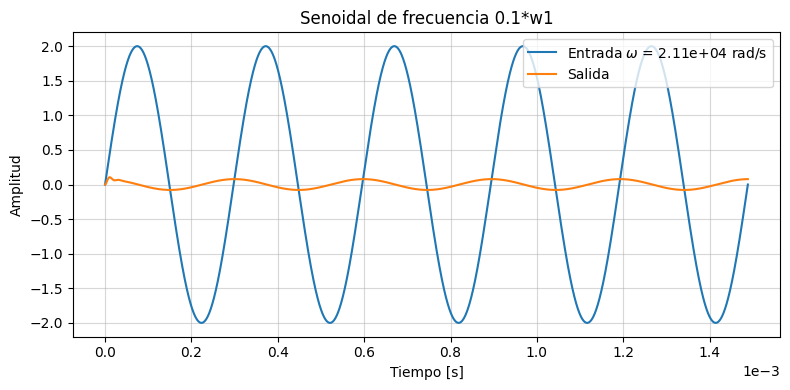

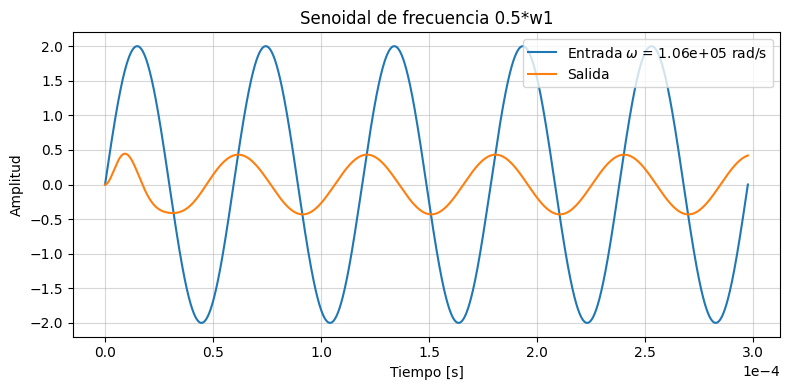

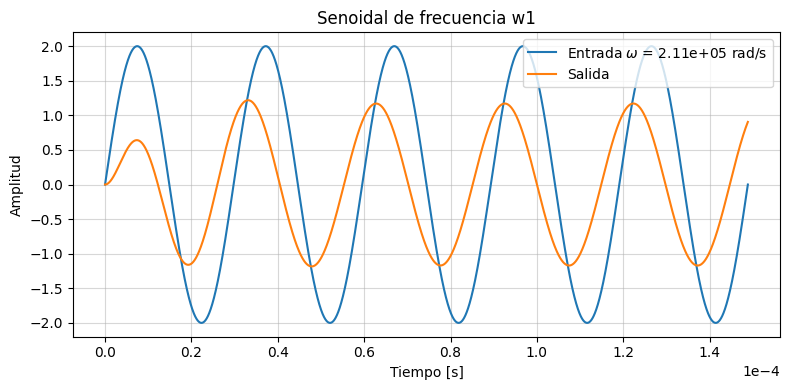

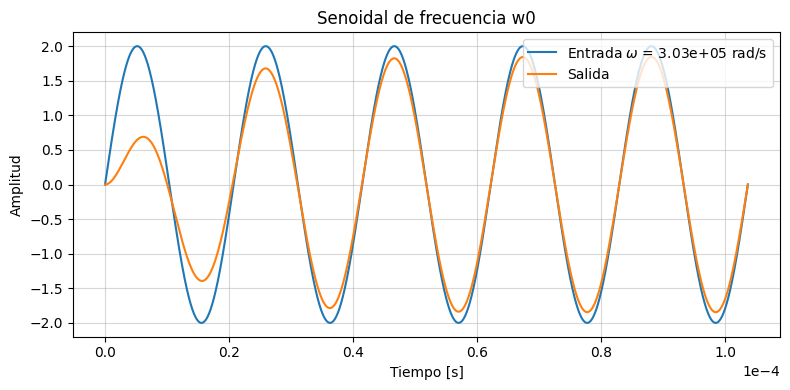

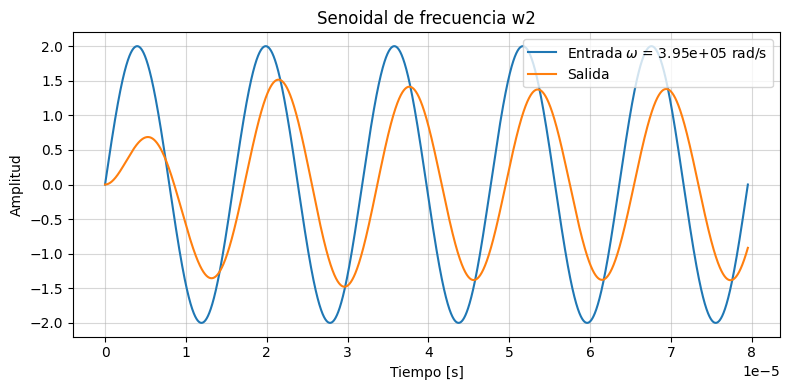

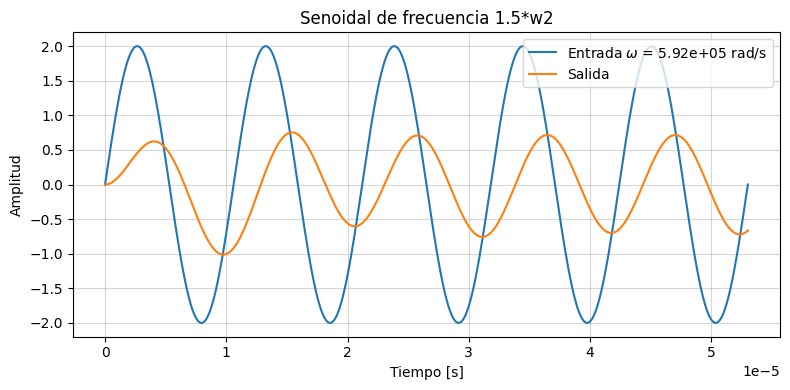

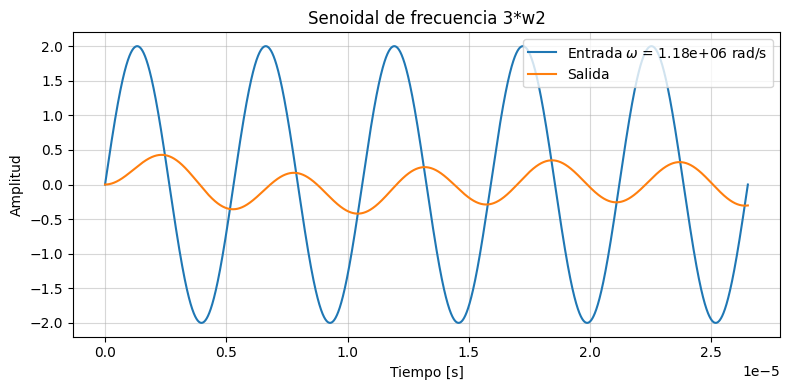

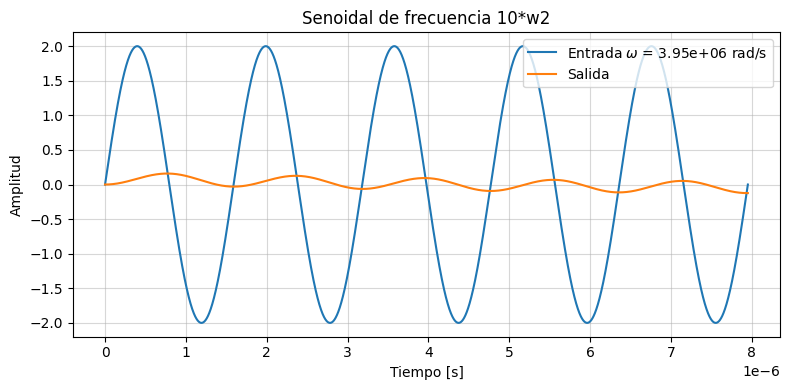

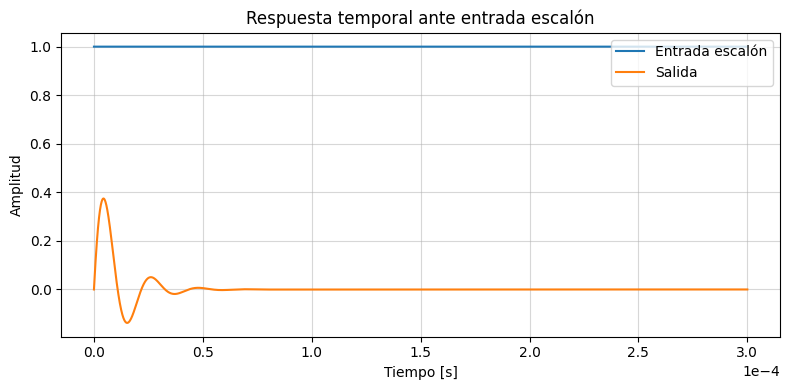

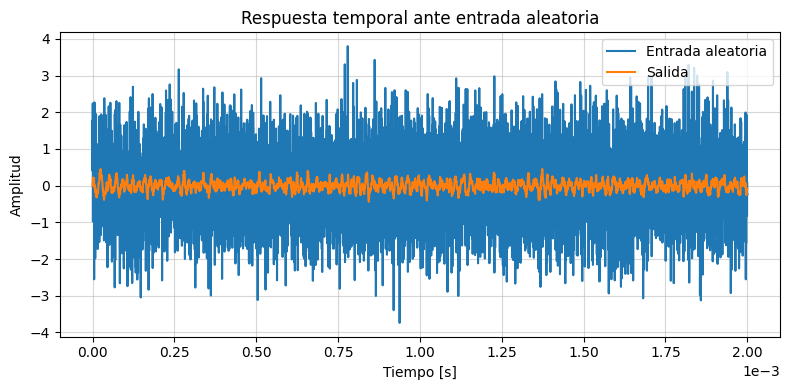

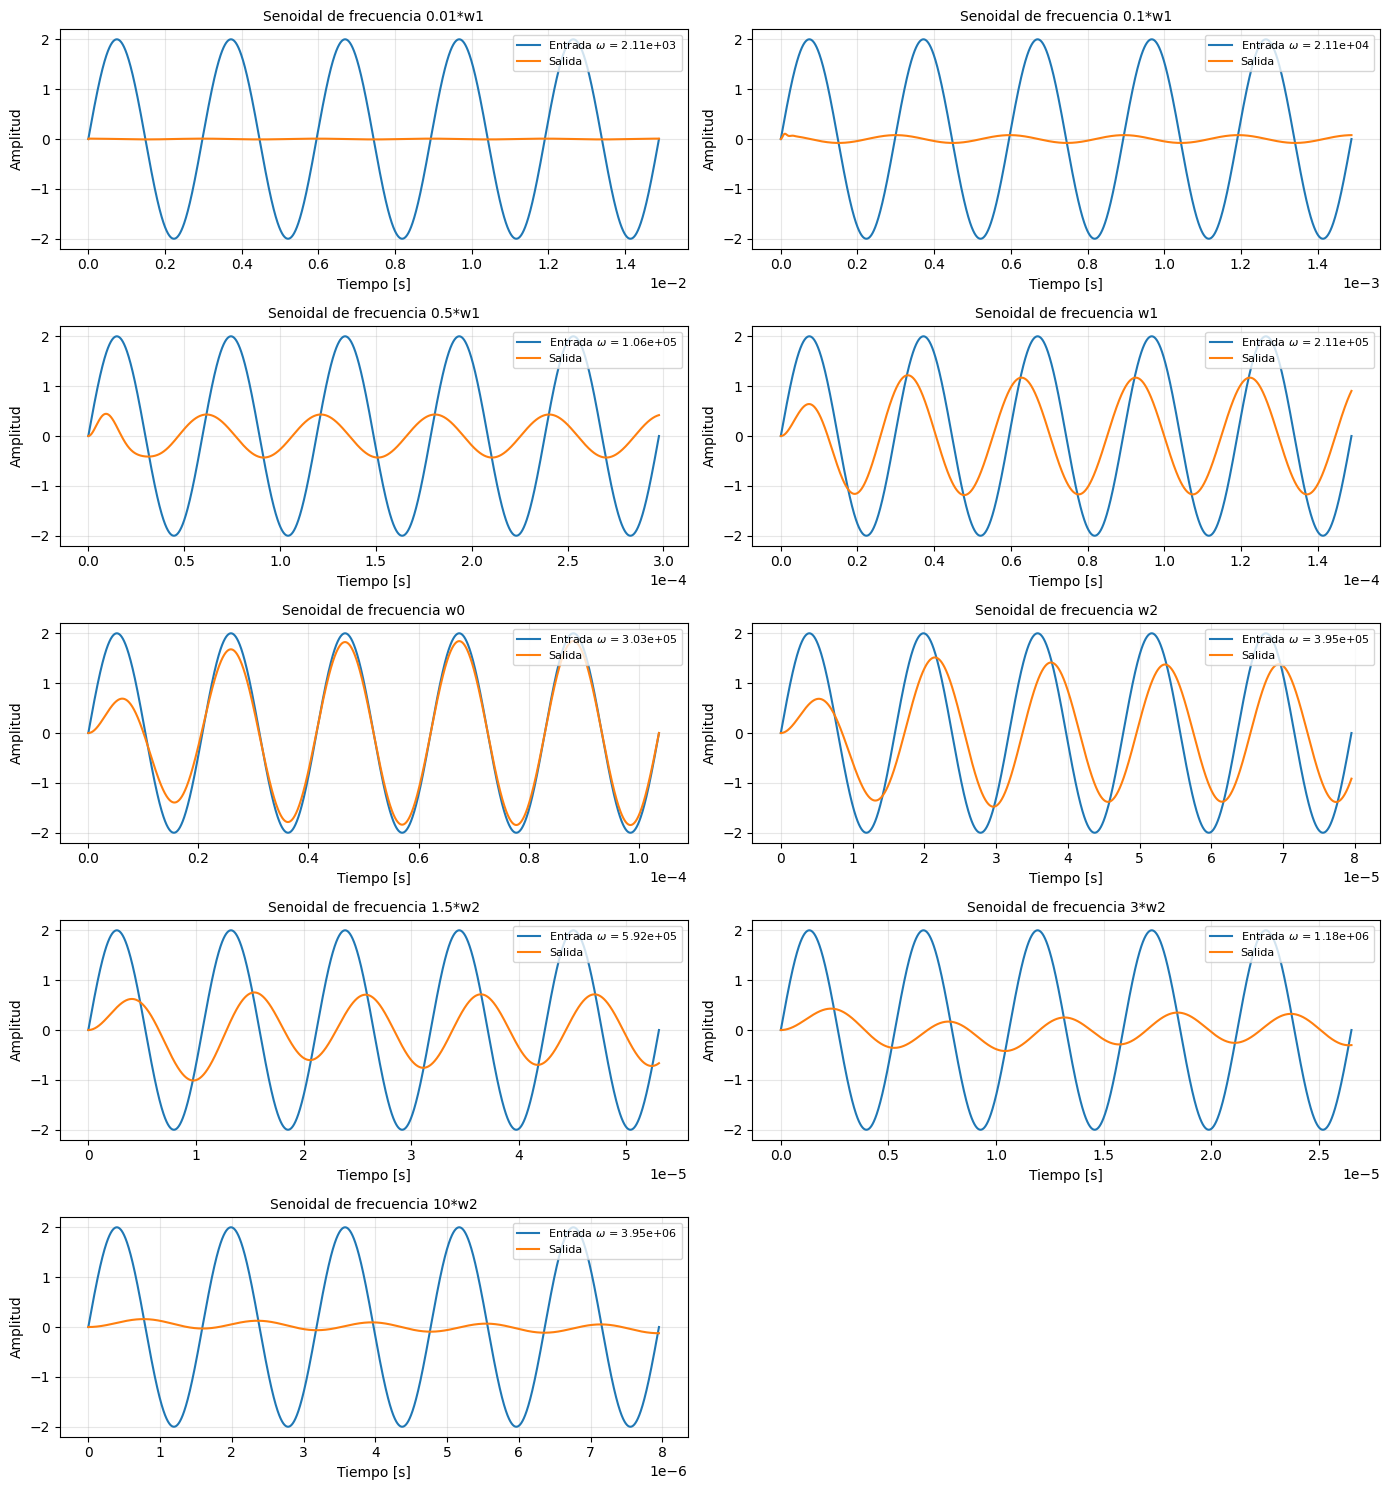

In [ ]:
omega_1 = 0.01 * w1
omega_2 = 0.10 * w1
omega_3 = 0.50 * w1
omega_4 = w1
omega_5 = w0
omega_6 = w2
omega_7 = 1.50 * w2
omega_8 = 3.00 * w2
omega_9 = 10.0 * w2

omegas = [omega_1, omega_2, omega_3, omega_4, omega_5, omega_6, omega_7, omega_8, omega_9]

titulos = [
    'Senoidal de frecuencia 0.01*w1',
    'Senoidal de frecuencia 0.1*w1',
    'Senoidal de frecuencia 0.5*w1',
    'Senoidal de frecuencia w1',
    'Senoidal de frecuencia w0',
    'Senoidal de frecuencia w2',
    'Senoidal de frecuencia 1.5*w2',
    'Senoidal de frecuencia 3*w2',
    'Senoidal de frecuencia 10*w2'
]

A = 2

periodo_1 = 2*np.pi / omega_1
tiempo_1 = np.linspace(0, 5*periodo_1, 5000)
senal_entrada_1 = A * np.sin(omega_1 * tiempo_1)
tiempo_salida_1, senal_salida_1, _ = signal.lsim(sys_tf, U=senal_entrada_1, T=tiempo_1)

periodo_2 = 2*np.pi / omega_2
tiempo_2 = np.linspace(0, 5*periodo_2, 5000)
senal_entrada_2 = A * np.sin(omega_2 * tiempo_2)
tiempo_salida_2, senal_salida_2, _ = signal.lsim(sys_tf, U=senal_entrada_2, T=tiempo_2)

periodo_3 = 2*np.pi / omega_3
tiempo_3 = np.linspace(0, 5*periodo_3, 5000)
senal_entrada_3 = A * np.sin(omega_3 * tiempo_3)
tiempo_salida_3, senal_salida_3, _ = signal.lsim(sys_tf, U=senal_entrada_3, T=tiempo_3)

periodo_4 = 2*np.pi / omega_4
tiempo_4 = np.linspace(0, 5*periodo_4, 5000)
senal_entrada_4 = A * np.sin(omega_4 * tiempo_4)
tiempo_salida_4, senal_salida_4, _ = signal.lsim(sys_tf, U=senal_entrada_4, T=tiempo_4)

periodo_5 = 2*np.pi / omega_5
tiempo_5 = np.linspace(0, 5*periodo_5, 5000)
senal_entrada_5 = A * np.sin(omega_5 * tiempo_5)
tiempo_salida_5, senal_salida_5, _ = signal.lsim(sys_tf, U=senal_entrada_5, T=tiempo_5)

periodo_6 = 2*np.pi / omega_6
tiempo_6 = np.linspace(0, 5*periodo_6, 5000)
senal_entrada_6 = A * np.sin(omega_6 * tiempo_6)
tiempo_salida_6, senal_salida_6, _ = signal.lsim(sys_tf, U=senal_entrada_6, T=tiempo_6)

periodo_7 = 2*np.pi / omega_7
tiempo_7 = np.linspace(0, 5*periodo_7, 5000)
senal_entrada_7 = A * np.sin(omega_7 * tiempo_7)
tiempo_salida_7, senal_salida_7, _ = signal.lsim(sys_tf, U=senal_entrada_7, T=tiempo_7)

periodo_8 = 2*np.pi / omega_8
tiempo_8 = np.linspace(0, 5*periodo_8, 5000)
senal_entrada_8 = A * np.sin(omega_8 * tiempo_8)
tiempo_salida_8, senal_salida_8, _ = signal.lsim(sys_tf, U=senal_entrada_8, T=tiempo_8)

periodo_9 = 2*np.pi / omega_9
tiempo_9 = np.linspace(0, 5*periodo_9, 5000)
senal_entrada_9 = A * np.sin(omega_9 * tiempo_9)
tiempo_salida_9, senal_salida_9, _ = signal.lsim(sys_tf, U=senal_entrada_9, T=tiempo_9)

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_1, senal_entrada_1, label=fr'Entrada $\omega$ = {omega_1:.2e} rad/s')
plt.plot(tiempo_salida_1, senal_salida_1, label='Salida')
plt.title(titulos[0])
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_2, senal_entrada_2, label=fr'Entrada $\omega$ = {omega_2:.2e} rad/s')
plt.plot(tiempo_salida_2, senal_salida_2, label='Salida')
plt.title(titulos[1])
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_3, senal_entrada_3, label=fr'Entrada $\omega$ = {omega_3:.2e} rad/s')
plt.plot(tiempo_salida_3, senal_salida_3, label='Salida')
plt.title(titulos[2])
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_4, senal_entrada_4, label=fr'Entrada $\omega$ = {omega_4:.2e} rad/s')
plt.plot(tiempo_salida_4, senal_salida_4, label='Salida')
plt.title(titulos[3])
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_5, senal_entrada_5, label=fr'Entrada $\omega$ = {omega_5:.2e} rad/s')
plt.plot(tiempo_salida_5, senal_salida_5, label='Salida')
plt.title(titulos[4])
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_6, senal_entrada_6, label=fr'Entrada $\omega$ = {omega_6:.2e} rad/s')
plt.plot(tiempo_salida_6, senal_salida_6, label='Salida')
plt.title(titulos[5])
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_7, senal_entrada_7, label=fr'Entrada $\omega$ = {omega_7:.2e} rad/s')
plt.plot(tiempo_salida_7, senal_salida_7, label='Salida')
plt.title(titulos[6])
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_8, senal_entrada_8, label=fr'Entrada $\omega$ = {omega_8:.2e} rad/s')
plt.plot(tiempo_salida_8, senal_salida_8, label='Salida')
plt.title(titulos[7])
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_9, senal_entrada_9, label=fr'Entrada $\omega$ = {omega_9:.2e} rad/s')
plt.plot(tiempo_salida_9, senal_salida_9, label='Salida')
plt.title(titulos[8])
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

tiempo_escalon = np.linspace(0, 300e-6, 5000)
senal_entrada_escalon = np.ones_like(tiempo_escalon)
tiempo_salida_escalon, senal_salida_escalon, _ = signal.lsim(sys_tf, U=senal_entrada_escalon, T=tiempo_escalon)

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_escalon, senal_entrada_escalon, label='Entrada escalón')
plt.plot(tiempo_salida_escalon, senal_salida_escalon, label='Salida')
plt.title('Respuesta temporal ante entrada escalón')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ============================================================
# RESPUESTA A ENTRADA ALEATORIA
# ============================================================
tiempo_aleatorio = np.linspace(0, 2e-3, 8000)
np.random.seed(0)
senal_entrada_aleatoria = np.random.randn(len(tiempo_aleatorio))
tiempo_salida_aleatoria, senal_salida_aleatoria, _ = signal.lsim(sys_tf, U=senal_entrada_aleatoria, T=tiempo_aleatorio)

plt.figure(figsize=(8, 4))
plt.plot(tiempo_salida_aleatoria, senal_entrada_aleatoria, label='Entrada aleatoria')
plt.plot(tiempo_salida_aleatoria, senal_salida_aleatoria, label='Salida')
plt.title('Respuesta temporal ante entrada aleatoria')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.5)
plt.gca().ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(5, 2, figsize=(14, 15))
axs = axs.ravel()

axs[0].plot(tiempo_salida_1, senal_entrada_1, label=fr'Entrada $\omega$ = {omega_1:.2e}')
axs[0].plot(tiempo_salida_1, senal_salida_1, label='Salida')
axs[0].set_title(titulos[0], fontsize=10)
axs[0].set_xlabel('Tiempo [s]')
axs[0].set_ylabel('Amplitud')
axs[0].grid(True, alpha=0.3)
axs[0].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
axs[0].legend(loc='upper right', fontsize=8)

axs[1].plot(tiempo_salida_2, senal_entrada_2, label=fr'Entrada $\omega$ = {omega_2:.2e}')
axs[1].plot(tiempo_salida_2, senal_salida_2, label='Salida')
axs[1].set_title(titulos[1], fontsize=10)
axs[1].set_xlabel('Tiempo [s]')
axs[1].set_ylabel('Amplitud')
axs[1].grid(True, alpha=0.3)
axs[1].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
axs[1].legend(loc='upper right', fontsize=8)

axs[2].plot(tiempo_salida_3, senal_entrada_3, label=fr'Entrada $\omega$ = {omega_3:.2e}')
axs[2].plot(tiempo_salida_3, senal_salida_3, label='Salida')
axs[2].set_title(titulos[2], fontsize=10)
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_ylabel('Amplitud')
axs[2].grid(True, alpha=0.3)
axs[2].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
axs[2].legend(loc='upper right', fontsize=8)

axs[3].plot(tiempo_salida_4, senal_entrada_4, label=fr'Entrada $\omega$ = {omega_4:.2e}')
axs[3].plot(tiempo_salida_4, senal_salida_4, label='Salida')
axs[3].set_title(titulos[3], fontsize=10)
axs[3].set_xlabel('Tiempo [s]')
axs[3].set_ylabel('Amplitud')
axs[3].grid(True, alpha=0.3)
axs[3].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
axs[3].legend(loc='upper right', fontsize=8)

axs[4].plot(tiempo_salida_5, senal_entrada_5, label=fr'Entrada $\omega$ = {omega_5:.2e}')
axs[4].plot(tiempo_salida_5, senal_salida_5, label='Salida')
axs[4].set_title(titulos[4], fontsize=10)
axs[4].set_xlabel('Tiempo [s]')
axs[4].set_ylabel('Amplitud')
axs[4].grid(True, alpha=0.3)
axs[4].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
axs[4].legend(loc='upper right', fontsize=8)

axs[5].plot(tiempo_salida_6, senal_entrada_6, label=fr'Entrada $\omega$ = {omega_6:.2e}')
axs[5].plot(tiempo_salida_6, senal_salida_6, label='Salida')
axs[5].set_title(titulos[5], fontsize=10)
axs[5].set_xlabel('Tiempo [s]')
axs[5].set_ylabel('Amplitud')
axs[5].grid(True, alpha=0.3)
axs[5].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
axs[5].legend(loc='upper right', fontsize=8)

axs[6].plot(tiempo_salida_7, senal_entrada_7, label=fr'Entrada $\omega$ = {omega_7:.2e}')
axs[6].plot(tiempo_salida_7, senal_salida_7, label='Salida')
axs[6].set_title(titulos[6], fontsize=10)
axs[6].set_xlabel('Tiempo [s]')
axs[6].set_ylabel('Amplitud')
axs[6].grid(True, alpha=0.3)
axs[6].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
axs[6].legend(loc='upper right', fontsize=8)

axs[7].plot(tiempo_salida_8, senal_entrada_8, label=fr'Entrada $\omega$ = {omega_8:.2e}')
axs[7].plot(tiempo_salida_8, senal_salida_8, label='Salida')
axs[7].set_title(titulos[7], fontsize=10)
axs[7].set_xlabel('Tiempo [s]')
axs[7].set_ylabel('Amplitud')
axs[7].grid(True, alpha=0.3)
axs[7].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
axs[7].legend(loc='upper right', fontsize=8)

axs[8].plot(tiempo_salida_9, senal_entrada_9, label=fr'Entrada $\omega$ = {omega_9:.2e}')
axs[8].plot(tiempo_salida_9, senal_salida_9, label='Salida')
axs[8].set_title(titulos[8], fontsize=10)
axs[8].set_xlabel('Tiempo [s]')
axs[8].set_ylabel('Amplitud')
axs[8].grid(True, alpha=0.3)
axs[8].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
axs[8].legend(loc='upper right', fontsize=8)

axs[9].axis('off')

plt.tight_layout()
plt.show()